### Experiments list
1. signal_length = 100, 100 epochs of 100_000 signals, lr scheduler with 30, 70 that starts with 1e-2, weight decay of 1e-3 -> converges to 10 eigenvectors
2. signal_length = 100, 100 epochs of 100_000 signals, smoothing sigma = 3, lr scheduler with 30, 70 that starts with 1e-2, weight decay of 1e-3 -> converges to 15 eigenvectors

In [1]:
import torch
import tqdm

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pytorch_lightning as pl

from src.losses.losses import DirichletLoss
from src.models.laplacian_net import LaplacianNet
from src.models.siren import SirenModel
from torch.utils.data import DataLoader, TensorDataset, Dataset
from scipy.ndimage import gaussian_filter

signal_length = 256

In [2]:
def generate_smooth_signal(length=1000, smoothing_sigma=2.0, num_samples=1000):
    signals = []
    for _ in tqdm.tqdm(range(num_samples)):
        noise = np.random.rand(length)
        smooth_signal = gaussian_filter(noise, sigma=smoothing_sigma)
        signals.append(smooth_signal)
        # x = np.linspace(0, 1, length)
        # y_start = smooth_signal[0]
        # y_end = smooth_signal[-1]
        # linear_trend = (y_end - y_start) * x
        
        # # Subtract the linear trend from the signal
        # detrended_signal = smooth_signal - linear_trend
        # signals.append(detrended_signal)
    # return np.array(detrended_signal)
    return np.array(smooth_signal)

class SmoothSignalDataset(Dataset):
    def __init__(self, length=100, smoothing_sigma=2.0, num_samples=1000):
        self.length = length
        self.smoothing_sigma = smoothing_sigma
        self.num_samples = num_samples
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        # Generate a smooth signal on the fly
        noise = np.random.rand(self.length)
        smooth_signal = gaussian_filter(noise, sigma=self.smoothing_sigma)
        # Compute the linear trend between the first and last points
        # x = np.linspace(0, 1, self.length)
        # y_start = smooth_signal[0]
        # y_end = smooth_signal[-1]
        # linear_trend = (y_end - y_start) * x
        
        # # Subtract the linear trend from the signal
        # detrended_signal = smooth_signal - linear_trend

        # return torch.tensor(detrended_signal, dtype=torch.float32)
        return torch.tensor(smooth_signal, dtype=torch.float32)

In [5]:
# Generate synthetic data for demonstration
num_samples = 1_000_000
smoothing_sigma = 8

dataset = SmoothSignalDataset(signal_length, smoothing_sigma, num_samples)

100%|██████████| 1/1 [00:00<00:00, 2775.85it/s]


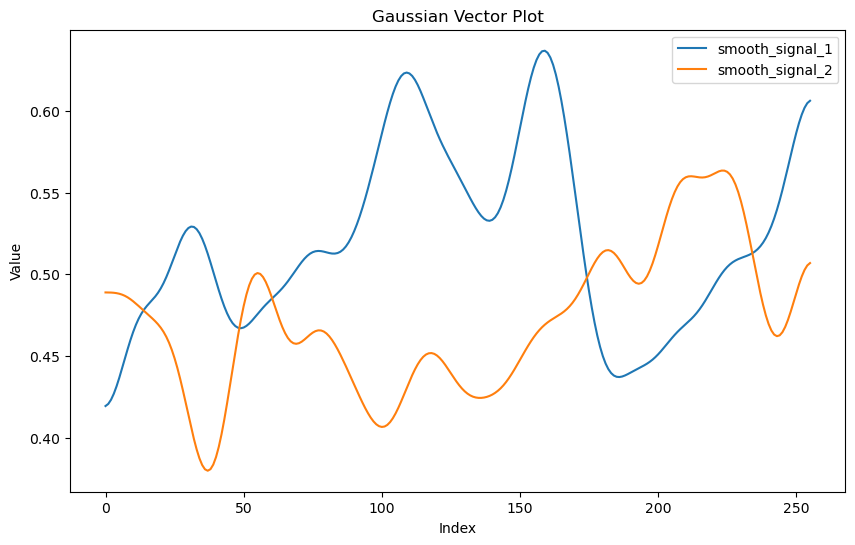

In [6]:
smooth_signal_1 = generate_smooth_signal(length=signal_length, smoothing_sigma=smoothing_sigma, num_samples=1).reshape(-1)
smooth_signal_2 = generate_smooth_signal(length=signal_length, smoothing_sigma=smoothing_sigma, num_samples=1).reshape(-1)
plt.figure(figsize=(10, 6))
plt.plot(smooth_signal_1, label='smooth_signal_1')
plt.plot(smooth_signal_2, label='smooth_signal_2')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Gaussian Vector Plot')
plt.legend()
plt.show()

In [5]:
hidden_dim = 16
hidden_layers = 1
batch_size = 1024
k = 15

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

# Model initialization
model = LaplacianNet(input_dim=signal_length, hidden_dim=hidden_dim, hidden_layers=hidden_layers, k=k, lr=1e-2, weight_decay=1e-3)
# model = SirenModel(in_features=signal_length, hidden_features=hidden_dim, hidden_layers=5, out_features=k*signal_length,k=10, lr=1e-4, weight_decay=1e-3)

# Trainer
trainer = pl.Trainer(max_epochs=100, log_every_n_steps=10)

# Train the model
trainer.fit(model, dataloader)

TypeError: LaplacianNet.__init__() got an unexpected keyword argument 'input_dim'

100%|██████████| 1/1 [00:00<00:00, 3070.50it/s]


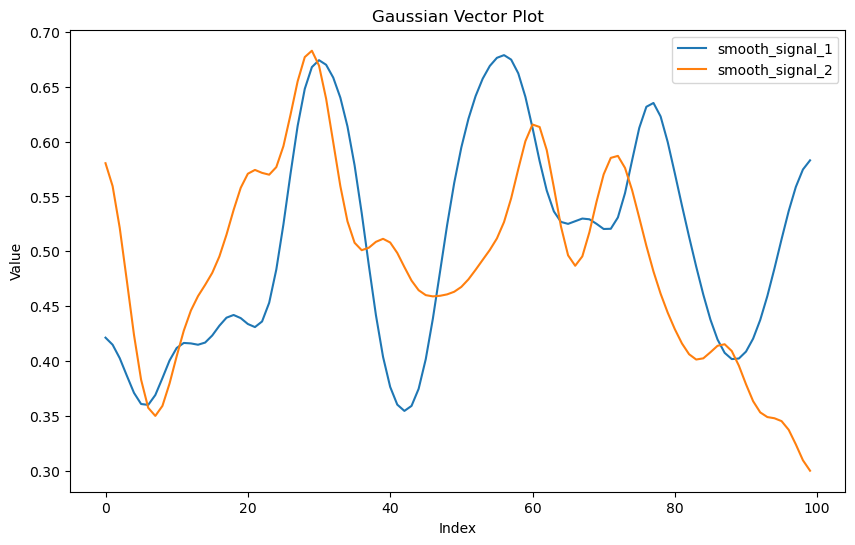

In [11]:
smooth_signal_1 = generate_smooth_signal(length=signal_length, smoothing_sigma=smoothing_sigma, num_samples=1).reshape(-1)
smooth_signal_2 = generate_smooth_signal(length=signal_length, smoothing_sigma=smoothing_sigma, num_samples=1).reshape(-1)
plt.figure(figsize=(10, 6))
plt.plot(smooth_signal_1, label='smooth_signal_1')
plt.plot(smooth_signal_2, label='smooth_signal_2')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Gaussian Vector Plot')
plt.legend()
plt.show()

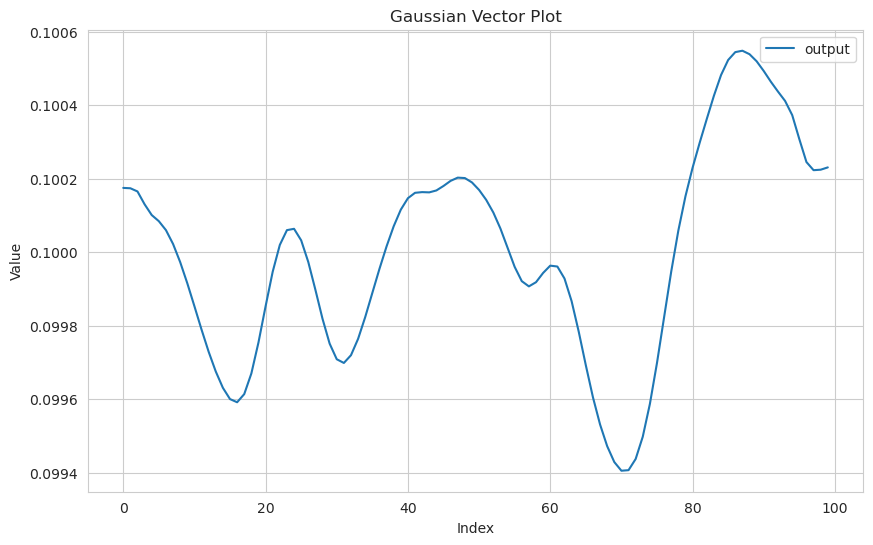

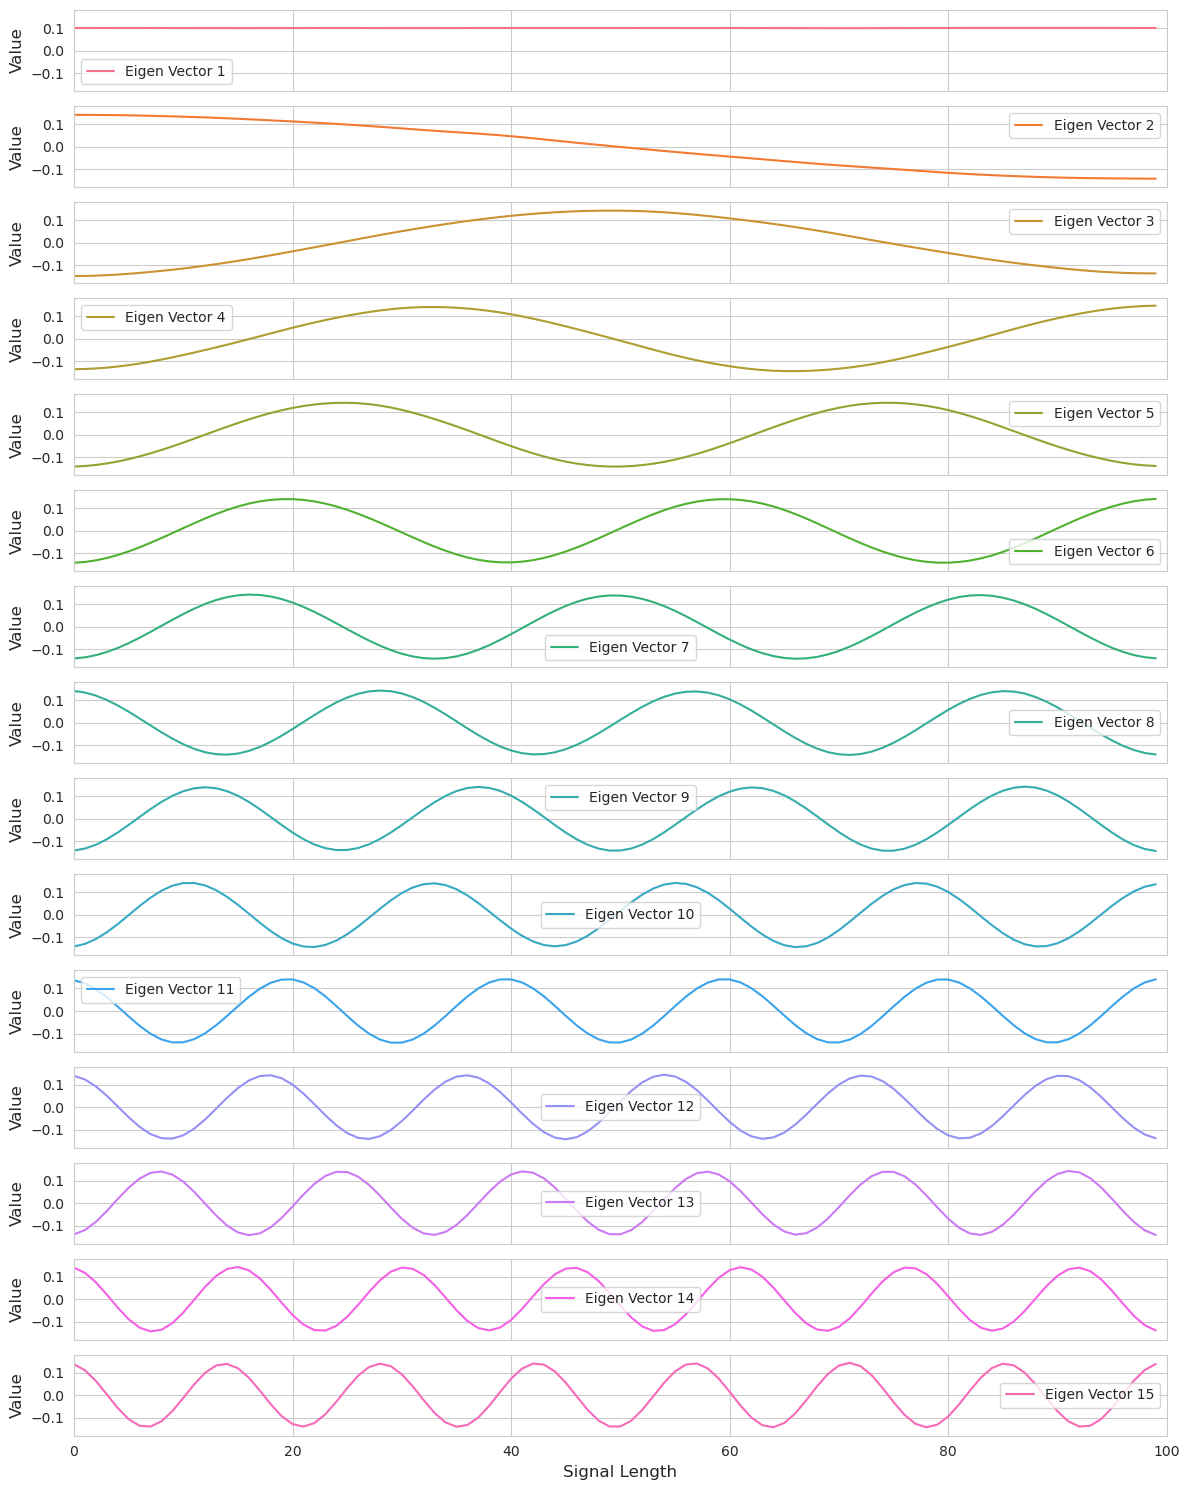

In [12]:
basis = model(torch.from_numpy(smooth_signal_1).float())
basis = basis.detach().numpy()
basis = basis.reshape(k, signal_length)

sns.set_style('whitegrid')
palette = sns.color_palette('husl', k)  # Generate a diverse color palette

plt.figure(figsize=(10, 6))
plt.plot(basis[0], label='output')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Gaussian Vector Plot')
plt.legend()
plt.show()


fig, axes = plt.subplots(k, 1, figsize=(12, 15), sharex=True)
for i in range(k):
    sns.lineplot(x=np.arange(signal_length), y=basis[i], ax=axes[i], color=palette[i], label=f'Eigen Vector {i+1}')
    axes[i].set_ylabel('Value', fontsize=12)
    axes[i].legend(fontsize=10)
    axes[i].tick_params(axis='both', labelsize=10)
    axes[i].set_ylim(-.18, .18)  # Example range; customize as needed

# Customize x-axis and overall layout
axes[-1].set_xlabel('Signal Length', fontsize=12)
axes[-1].set_xlim(0, signal_length)

plt.tight_layout()
plt.show()

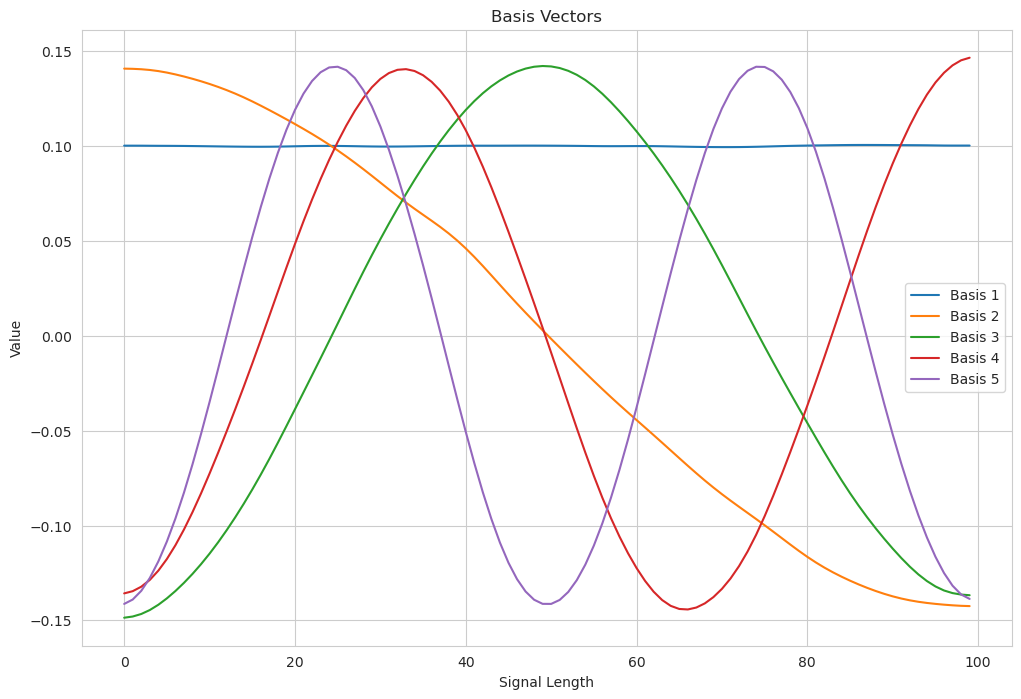

In [13]:
basis = model(torch.from_numpy(smooth_signal_2).float())
basis = basis.detach().numpy()
basis = basis.reshape(k, signal_length)

plt.figure(figsize=(12, 8))
for i in range(5):
    plt.plot(basis[i], label=f'Basis {i+1}')
plt.xlabel('Signal Length')
plt.ylabel('Value')
plt.title('Basis Vectors')
plt.legend()
plt.show()

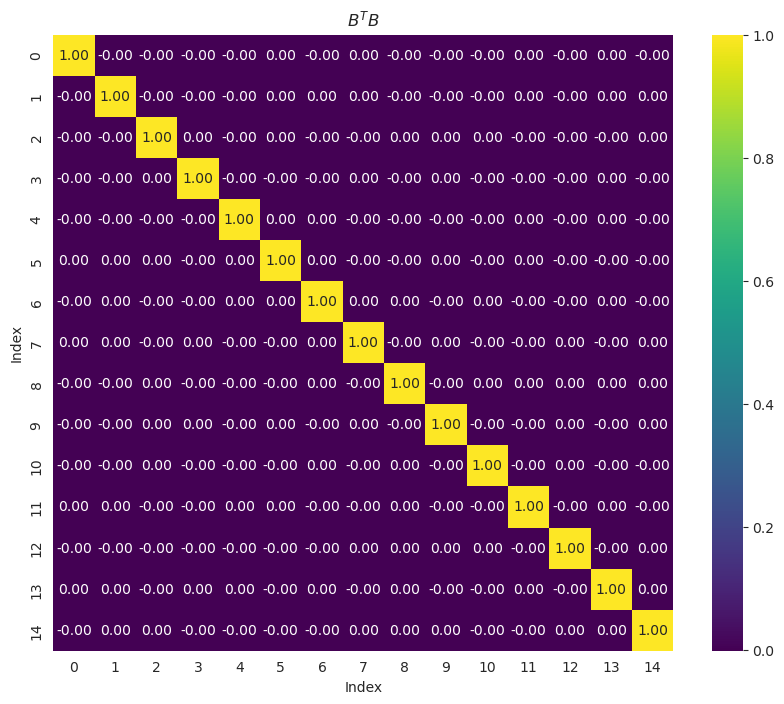

In [14]:
# Compute the dot product of the basis vectors
dot_product_matrix = np.dot(basis, basis.T)
plt.figure(figsize=(10, 8))
sns.heatmap(dot_product_matrix, annot=True, fmt=".2f", cmap='viridis')
plt.title('$B^{T} B$')
plt.xlabel('Index')
plt.ylabel('Index')
plt.show()

1. Check the reconstruction error after training, compare with the training reconstruction error.
2. Orthogonality sanity check.
3. Random $k$ reconstruction to induce sorting.
4. Good vs. Bad signals